In [2]:
import os
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
remove_attention_failers = 0

In [4]:
test = []
def extract_basic_info(csv_path):
    df = pd.read_csv(csv_path)
    

    free_texts = df['explanation_box.text'].dropna().tolist()


    # Feedback (free text response about experiment)
    if 'feedback_text.text' in df.columns:
        feedback = df['feedback_text.text'].dropna().tolist()
    else:
        print(f"Missing 'feedback_text.text' in {os.path.basename(csv_path)}")
        fail_text = f"Missing 'feedback_text.text' in {os.path.basename(csv_path)}"
        test.append(fail_text)
        feedback = []

    #Actual fertility score (fertility on each training trial)
    fertility_score = df['fertility_score'].dropna().tolist() [:-1]
    
    # Training trial stop time (time it took to finish the training loop)
    isi_values = df['ISI.stopped'].dropna().tolist()

    #Get the ISI value for the last training trial, store it
    trial_stop_time = isi_values[-1] if isi_values else np.nan

    #First row with a non-empty value in 'images_list', which shows the order of testing images presented
    images_row = df[df['images_list'].notna()].iloc[0] if not df[df['images_list'].notna()].empty else None

    #Turn the images from PNGs to names
    images = [img.split('/')[-1].replace('.png','') for img in images_row['images_list'].split(',')]

    #First row with a non-empty value in 'sliderRatings', which shows the ratings for testing images
    ratings_row = df[df['sliderRatings'].notna()].iloc[0] if not df[df['sliderRatings'].notna()].empty else None

    #Turn the ratings into floats split by commas
    ratings = [float(r) for r in ratings_row['sliderRatings'].strip('[]').split(',')]

    #Across the training trials, add information about features (what actual feature values were shown)
    train_feet = df['feet'].dropna().tolist() [:-1]
    train_stripes = df['stripes'].dropna().tolist() [:-1]

    #Across the training trials, add information about feature relevance
    train_categories =  df['category'].dropna().tolist() [:-1]


    #Extracting the relevant and irrelevant feature dimension info
    dims = {}
    cols = ['relevant_dim', 'irrelevant_dim', 
            'feet_high', 'stripes_low', 
            'stripes_high', 'feet_low']

    for col in cols:
        vals = df[col].dropna().unique()

        if len(vals) == 0:
            dims[col] = np.nan
            print(f"Warning: No values found in {col}")

        elif len(vals) == 1:
            dims[col] = vals[0]

        else:
            warnings.warn(
                f"Multiple values found in {col}: {vals}"
            )
            dims[col] = vals[0] 

    print(dims)

    #Categories for the testing images, in the order shown
    test_categories = images_row['testing_categories'].split(',')

    #Write condition (this is the unique identifier for a certain order of training trials)
    condition = images_row['condition'] if images_row is not None and 'condition' in images_row else np.nan

    #Add in the order of images during training
    training_image_order = [img.split('/')[-1].replace('.png','') 
                        for img in df['image_file'].dropna().tolist()] [:-1]
    
    #Updated code to get slider responses (subjective reports of feature relevance)
    df['feature_clean'] = (
    df['feature']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({'stripe': 'stripes'})
)
    slider_responses = {}
    features = ['feet', 'stripes']

    for feat in features:
        sub = df[df['feature_clean'] == feat]

        for suffix in ['', '_mid']:

            # 1. discrete
            disc_col = f'discrete_slider{suffix}.response'
            disc = sub[disc_col]

            disc_val = (
                disc[disc.notna() & (disc != "")].iloc[0]
                if (disc.notna() & (disc != "")).any()
                else np.nan
            )

            slider_responses[f'{feat}_discrete_slider{suffix}.response'] = disc_val

            # 2. direction
            dir_col = f'direction_response_label{suffix}'

            if dir_col not in sub.columns:
                warnings.warn(
                    f"Column '{dir_col}' not found for feature '{feat}' in {os.path.basename(csv_path)}"
                )
                dirc_val = np.nan
            else:
                dirc = sub[dir_col]
                dirc_val = (
                    dirc[dirc.notna() & (dirc != "")].iloc[0]
                    if (dirc.notna() & (dirc != "")).any() and disc_val != 'No'
                    else np.nan
                )

            slider_responses[f'{feat}_direction_slider{suffix}.response'] = dirc_val

            # 3. continuous
            cont_col = f'continuous_slider{suffix}.response'
            cont = sub[cont_col]

            cont_val = (
                cont[cont.notna() & (cont != "")].iloc[0]
                if (cont.notna() & (cont != "")).any() and disc_val != 'No'
                else np.nan
            )

            slider_responses[f'{feat}_continuous_slider{suffix}.response'] = cont_val

    #Adding attention check result
    att_rows = df[df['button_3_correct.numClicks'].notna()]
    print('attention', att_rows)
    if not att_rows.empty:
        att_val = att_rows.iloc[0]['button_3_correct.numClicks']
    else:
        att_val = np.nan
    attention_check = 1 if att_val == 1 else 0


    #Spontaneous explain/predict ratings:
    cogpro_predict = df['cogpro_predict.response'].dropna().iloc[0]
    cogpro_explain = df['cogpro_explain.response'].dropna().iloc[0]
    cogpro_predict = float(pd.Series([cogpro_predict]).astype(str).str.extract(r'(\d+\.?\d*)').iloc[0,0])
    cogpro_explain = float(pd.Series([cogpro_explain]).astype(str).str.extract(r'(\d+\.?\d*)').iloc[0,0])
    #stimuli_clicks = float(pd.Series([stimuli_clicks]).astype(str).str.extract(r'(\d+\.?\d*)').iloc[0,0])


    result = {
        'participant': os.path.basename(csv_path)[:3],
        'free_texts': free_texts,
        'feedback': feedback,
        'fertility_score': fertility_score,
        'trial_stop_time': trial_stop_time,
        'testing_image_order': images,
        'testing_responses': ratings,
        'training_categories': train_categories,
        'training_feet': train_feet,
        'training_stripes': train_stripes,
        'testing_categories': test_categories,
        'conditionOrder': condition,
        'training_image_order': training_image_order,
        'attention_check': attention_check,
        'cogpro_predict': cogpro_predict,
        'cogpro_explain': cogpro_explain,

        **dims
        
    }
    result.update(slider_responses)
    return result

topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study5.0'
dates = [
    '2026-06-04',
    '2026-06-08',
    '2026-06-10'
]
datadir = os.path.join(topdir, f'data/{study}/Accommodate')
cleaneddir = os.path.join(topdir, f'data/{study}/Cleaned')
all_participants = []

for fname in os.listdir(datadir):
    if fname.endswith('.csv') and fname:
        participant_id = fname[:3]
        if not any(d in fname for d in dates):
            continue
        csv_path = os.path.join(datadir, fname)
        print(csv_path)
        info = extract_basic_info(csv_path)
        all_participants.append(info)

df_all = pd.DataFrame(all_participants)
if remove_attention_failers:
    df_all = df_all[df_all['attention_check'] == 1]
    df_all.to_csv(os.path.join(cleaneddir, f'{study}AccommodateAttRemoved.csv'), index=False)
else:
    df_all.to_csv(os.path.join(cleaneddir, f'{study}Accommodate.csv'), index=False)

print(df_all[df_all['attention_check'] == 1])
print(test)

/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Study5.0/Accommodate/226_explain2_2026-06-04_13h11.50.946.csv
{'relevant_dim': 'stripes', 'irrelevant_dim': 'feet', 'feet_high': 'C', 'stripes_low': 'E', 'stripes_high': 'W', 'feet_low': 'F'}
attention    consent_survey.block_1/consentChoice  condition                     date  \
30                                  NaN        226  2026-06-04_13h11.50.946   

     expName psychopyVersion     OS  frameRate              PROLIFIC_PID  \
30  explain2        2025.1.1  Win32  48.309179  6a18a14c1a4171a5a1de1479   

                    STUDY_ID                SESSION_ID  ...  \
30  6a21d5d599f968bc9253a998  6a21dba7b9991d810ba05802  ...   

    continue_cogpro.timesOn  continue_cogpro.timesOff  Goodbye_Screen.started  \
30                      NaN                       NaN                     NaN   

    Goodbye_Screen.stopped  feedback_text.text button_end.numClicks  \
30                     NaN                 NaN                  NaN   

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label' not found for feature 'feet' in 226_explain2_2026-06-04_13h11.50.946.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'feet' in 226_explain2_2026-06-04_13h11.50.946.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label' not found for feature 'stripes' in 226_explain2_2026-06-04_13h11.50.946.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'stripes' in 226_explain2_2026-06-04_13h11.50.946.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Colum

{'relevant_dim': 'feet', 'irrelevant_dim': 'stripes', 'feet_high': 'C', 'stripes_low': 'W', 'stripes_high': 'E', 'feet_low': 'F'}
attention    consent_survey.block_1/consentChoice  condition                     date  \
30                                  NaN         29  2026-06-04_13h05.35.592   

     expName psychopyVersion     OS  frameRate              PROLIFIC_PID  \
30  explain2        2025.1.1  Win32   59.88024  6a17bd73a3d3b9dd0dc0e8d1   

                    STUDY_ID                SESSION_ID  ...  \
30  6a21d5d599f968bc9253a998  6a21d98fe4377dbb5da1dc7f  ...   

    continue_cogpro.timesOn  continue_cogpro.timesOff  Goodbye_Screen.started  \
30                      NaN                       NaN                     NaN   

    Goodbye_Screen.stopped  feedback_text.text button_end.numClicks  \
30                     NaN                 NaN                  NaN   

   button_end.timesOn  button_end.timesOff  \
30                NaN                  NaN   

    survey_debrief.blo

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label' not found for feature 'feet' in 114_explain2_2026-06-04_13h25.35.644.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'feet' in 114_explain2_2026-06-04_13h25.35.644.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label' not found for feature 'stripes' in 114_explain2_2026-06-04_13h25.35.644.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'stripes' in 114_explain2_2026-06-04_13h25.35.644.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Colum

{'relevant_dim': 'feet', 'irrelevant_dim': 'stripes', 'feet_high': 'C', 'stripes_low': 'E', 'stripes_high': 'W', 'feet_low': 'F'}
attention    consent_survey.block_1/consentChoice  condition                     date  \
30                                  NaN         85  2026-06-04_16h04.40.481   

     expName psychopyVersion     OS  frameRate              PROLIFIC_PID  \
30  explain2        2025.1.1  Win32  60.240964  6a0b8d7c28be22f41d909740   

                    STUDY_ID                SESSION_ID  ...  \
30  6a21d5d599f968bc9253a998  6a21da18d6b74ee440b64b70  ...   

    continue_cogpro.timesOn  continue_cogpro.timesOff  Goodbye_Screen.started  \
30                      NaN                       NaN                     NaN   

    Goodbye_Screen.stopped  feedback_text.text button_end.numClicks  \
30                     NaN                 NaN                  NaN   

   button_end.timesOn  button_end.timesOff  \
30                NaN                  NaN   

    survey_debrief.blo

...

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label' not found for feature 'feet' in 042_explain2_2026-06-04_13h05.41.938.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'feet' in 042_explain2_2026-06-04_13h05.41.938.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label' not found for feature 'stripes' in 042_explain2_2026-06-04_13h05.41.938.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'stripes' in 042_explain2_2026-06-04_13h05.41.938.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Colum

{'relevant_dim': 'feet', 'irrelevant_dim': 'stripes', 'feet_high': 'F', 'stripes_low': 'W', 'stripes_high': 'E', 'feet_low': 'C'}
attention    consent_survey.block_1/consentChoice  condition                     date  \
30                                  NaN        199  2026-06-04_16h12.23.250   

     expName psychopyVersion     OS  frameRate              PROLIFIC_PID  \
30  explain2        2025.1.1  Win32  60.240964  573b2aae67421f0006185a9c   

                    STUDY_ID                SESSION_ID  ...  \
30  6a21d5d599f968bc9253a998  6a21db4ea8a6d93db762764e  ...   

    continue_cogpro.timesOn  continue_cogpro.timesOff  Goodbye_Screen.started  \
30                      NaN                       NaN                     NaN   

    Goodbye_Screen.stopped  feedback_text.text button_end.numClicks  \
30                     NaN                 NaN                  NaN   

   button_end.timesOn  button_end.timesOff  \
30                NaN                  NaN   

    survey_debrief.blo

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label' not found for feature 'feet' in 207_explain2_2026-06-04_16h09.57.979.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'feet' in 207_explain2_2026-06-04_16h09.57.979.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label' not found for feature 'stripes' in 207_explain2_2026-06-04_16h09.57.979.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'stripes' in 207_explain2_2026-06-04_16h09.57.979.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Colum

{'relevant_dim': 'feet', 'irrelevant_dim': 'stripes', 'feet_high': 'C', 'stripes_low': 'W', 'stripes_high': 'E', 'feet_low': 'F'}
attention    consent_survey.block_1/consentChoice  condition                     date  \
30                                  NaN        133  2026-06-04_14h40.30.381   

     expName psychopyVersion     OS  frameRate              PROLIFIC_PID  \
30  explain2        2025.1.1  Win32  60.240964  6998af19175ea049781b31fe   

                    STUDY_ID                SESSION_ID  ...  \
30  6a21d5d599f968bc9253a998  6a21f02fd6601235e19661d2  ...   

    continue_cogpro.timesOn  continue_cogpro.timesOff  Goodbye_Screen.started  \
30                      NaN                       NaN                     NaN   

    Goodbye_Screen.stopped  feedback_text.text button_end.numClicks  \
30                     NaN                 NaN                  NaN   

   button_end.timesOn  button_end.timesOff  \
30                NaN                  NaN   

    survey_debrief.blo

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'feet' in 144_explain2_2026-06-04_16h07.11.128.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'stripes' in 144_explain2_2026-06-04_16h07.11.128.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'feet' in 154_explain2_2026-06-04_16h07.47.563.csv
  warnings.warn(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_11050/1404637573.py:113: UserWarning: Column 'direction_response_label_mid' not found for feature 'stripes' in 154_explain2_2026-06-04_16h07.47.563.csv
  warnings.warn(


In [7]:
print(df_all['conditionOrder'])

0      183
1       75
2      100
3       61
4       97
      ... 
212    214
213    146
214    188
215    104
216    204
Name: conditionOrder, Length: 217, dtype: int64


In [26]:
participant_id = '017'

row = df_all[df_all['participant'] == participant_id]

free_texts = row['free_texts'].iloc[0] 
feedback = row['feedback'].iloc[0]
print(f"Free text responses for participant {participant_id}:")
for i, text in enumerate(free_texts, 1):
    print(f"Response {i}: {text}")

print(f"\nFeedback for participant {participant_id}: {feedback}")


Free text responses for participant 017:
Response 1: the reptile looks healthy with bright color,clear eyes and a strong body ,these visible features may suggest good health which could be linked to higher fertility score
Response 2: the reptile is green and because of its colour or body features might  indicate it is less healthy or less mature compared to the other 
Response 3: looks healthy with clear eyes and a strong body ..the features shows its in good condition
Response 4: the reptile has lower fertility score because its features might suggest it is less strong or healthy 
Response 5: reptile has average score because  it looks fairly healthy ,but some features might not be strong as those with higher fertility 
Response 6: the green reptile looks fairly healthy 
Response 7: the reptile might not look healthy or strong ..which could mean lower chances of reproduction 
Response 8: the reptile appears weaker and less healthy ...which could also suggest very low chances of reprod

In [18]:
for _, row in df_all.iterrows():
    participant_id = row['participant']
    feedback = row['feedback']

    print(f"\nFeedback: {feedback}")


Feedback: []

Feedback: ['I encountered an issue when hitting the "Shift" key when I began to type.\xa0 If my finger was too close to the "Enter" key, it was registering as my having hit the "Continue" button, which was not my intention.\xa0 I believe this happened on four occasions, so my "reason" was missing on these four entries.\xa0 I did find it confusing that it was not made more clear that participants were supposed to be focusing on physical characteristics when giving reasons.\xa0 I was coming up with things based on certain colors, but also why someone\'s fertility may have been higher or lower in general, not having anything to do with appearance.\xa0 Maybe I\'m the only one who found it confusing (it\'s been a long day).\xa0 Good luck with your research!']

Feedback: []

Feedback: []

Feedback: ["I genuinely didn't see their toes."]

Feedback: []

Feedback: []

Feedback: ['The only issue I ran into was the frequent inability to lower my phone keyboard, making it difficult 

In [ ]:
stim_info = [
    {
        'stimulus': stim,
        'rating': rating,
        'category': testing_categories
    }
    for stim, rating in zip(basic_info['image_order'], basic_info['ratings'])
]
df_stim = pd.DataFrame(stim_info)
avg_per_category = df_stim.groupby('category')['rating'].mean()
plt.figure(figsize=(6,4))
bars = plt.bar(avg_per_category.index, avg_per_category.values, color=['red','green','blue'], alpha=0.7)

# Add text labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{bar.get_height():.2f}", ha='center')

plt.ylabel('Average Rating')
plt.title('Average food ratings by Stimulus Category')
plt.ylim(0, 10)
plt.show()

<Figure size 640x480 with 0 Axes>

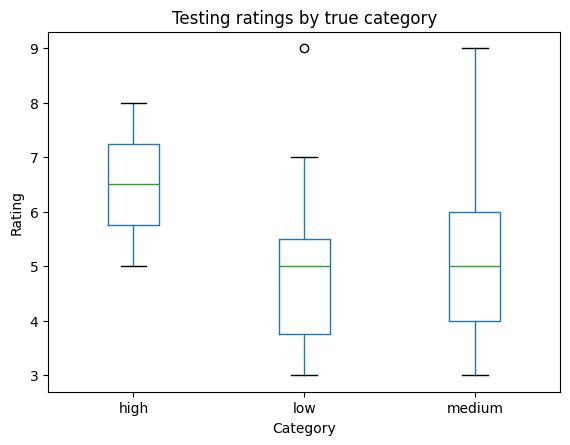

In [19]:
import pandas as pd
import numpy as np

def explode_testing(df):
    rows = []
    for _, row in df.iterrows():
        cats = row['testing_categories']
        ratings = row['testing_responses']

        if not isinstance(cats, list) or not isinstance(ratings, list):
            continue

        for i, (c, r) in enumerate(zip(cats, ratings)):
            rows.append({
                'participant': row['participant'],
                'trial': i,
                'category': c,
                'rating': r
            })

    return pd.DataFrame(rows)

df_test_long = explode_testing(df_all)

df_test_long.groupby('category')['rating'].agg(
    mean='mean',
    std='std',
    n='count'
).reset_index()
import matplotlib.pyplot as plt

plt.figure()
df_test_long.boxplot(
    column='rating',
    by='category',
    grid=False
)
plt.suptitle('')
plt.title('Testing ratings by true category')
plt.ylabel('Rating')
plt.xlabel('Category')
plt.show()



<Figure size 640x480 with 0 Axes>

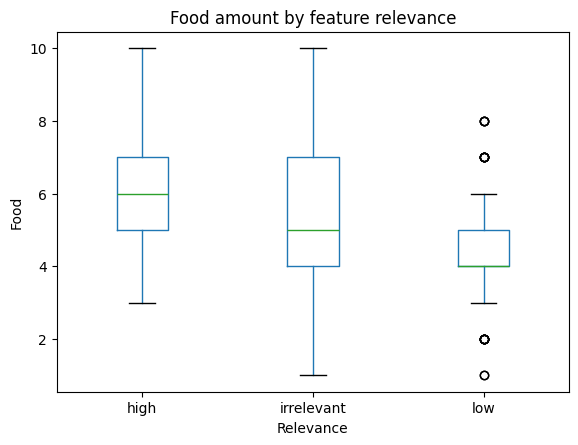

In [25]:
def explode_training(df):
    rows = []

    for _, row in df.iterrows():
        n_trials = len(row['food_amount'])

        for t in range(n_trials):
            rows.append({
                'participant': row['participant'],
                'trial': t,
                'category': row['training_categories'][t],
                'food': row['food_amount'][t],
                'tail_rel': row['training_tail'][t],
                'shape_rel': row['training_shape'][t],
                'color_rel': row['training_color'][t]
            })

    return pd.DataFrame(rows)

df_train_long = explode_training(df_all)
def get_relevance(code):
    if isinstance(code, str):
        if code.startswith('R'):
            return 'high'
        elif code.startswith('L'):
            return 'low'
        elif code.startswith('I'):
            return 'irrelevant'
    return np.nan

for feat in ['tail', 'shape', 'color']:
    df_train_long[f'{feat}_relevance'] = df_train_long[f'{feat}_rel'].apply(get_relevance)

df_rel_long = pd.melt(
    df_train_long,
    id_vars=['participant', 'trial', 'food'],
    value_vars=['tail_relevance', 'shape_relevance', 'color_relevance'],
    var_name='feature',
    value_name='relevance'
)

df_rel_long.groupby('relevance')['food'].agg(
    mean='mean',
    std='std',
    n='count'
)
plt.figure()
df_rel_long.boxplot(
    column='food',
    by='relevance',
    grid=False
)
plt.suptitle('')
plt.title('Food amount by feature relevance')
plt.ylabel('Food')
plt.xlabel('Relevance')
plt.show()



In [23]:
df_rel_long.groupby('relevance')['food'].mean()


relevance
high          6.303922
irrelevant    5.430000
low           4.520408
Name: food, dtype: float64

In [26]:
df_train_long.groupby('category')['food'].agg(
    mean='mean',
    std='std',
    n='count'
).reset_index()


,category,mean,std,n
0,high,7.230769,1.582598,26
1,low,3.666667,1.239448,24
2,medium,5.340000,1.408574,50


<Figure size 640x480 with 0 Axes>

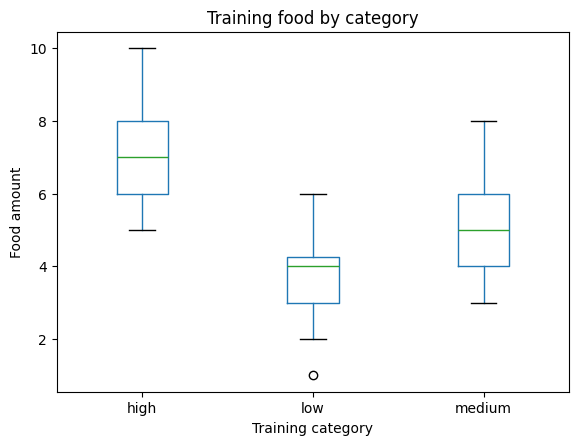

In [27]:
import matplotlib.pyplot as plt

plt.figure()
df_train_long.boxplot(
    column='food',
    by='category',
    grid=False
)
plt.suptitle('')
plt.title('Training food by category')
plt.ylabel('Food amount')
plt.xlabel('Training category')
plt.show()
